In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score 

import joblib

In [2]:
df=pd.read_csv("loan_approval_data.csv")
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [3]:
#Filling missing values
categorical_col=df.select_dtypes(include=["object"]).columns
numerical_col=df.select_dtypes(include=["number"]).columns

In [4]:
from sklearn.impute import SimpleImputer
cat_col=SimpleImputer(strategy="most_frequent")
df[categorical_col]=cat_col.fit_transform(df[categorical_col])

num_col=SimpleImputer(strategy='mean')
df[numerical_col]=num_col.fit_transform(df[numerical_col])

In [5]:
df.isnull().sum()


Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [6]:
df.sample(2)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
446,447.00,13130.0,5082.455789,Salaried,38.0,Single,1.0,647.0,4.0,0.55,8625.0,14298.0,1567.0,12.0,Home,Urban,Not Graduate,Female,Private,No
786,501.22,5391.0,3179.000000,Contract,23.0,Married,3.0,689.0,2.0,0.57,9650.0,45380.0,33177.0,24.0,Education,Urban,Not Graduate,Male,Private,No


Text(0.5, 1.0, 'Is Loan approved')

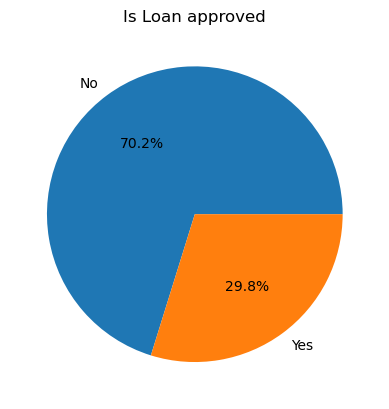

In [7]:
#EDA
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is Loan approved")

[Text(0, 0, '643'), Text(0, 0, '357')]

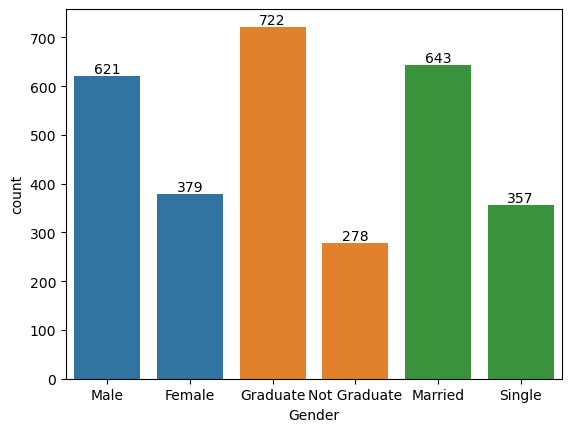

In [8]:
#analyze categories
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

edu_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_cnt)
ax.bar_label(ax.containers[1])

mat_cnt=df["Marital_Status"].value_counts()
ax=sns.barplot(mat_cnt)
ax.bar_label(ax.containers[2])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

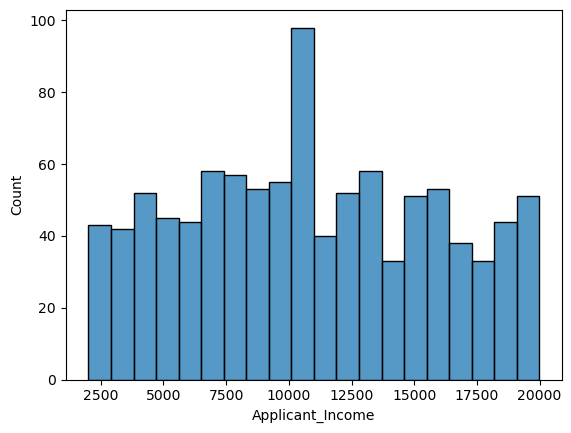

In [9]:
#analyze income 
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)



<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

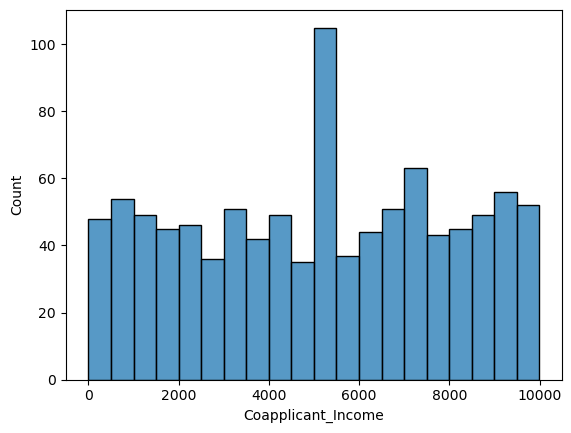

In [10]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

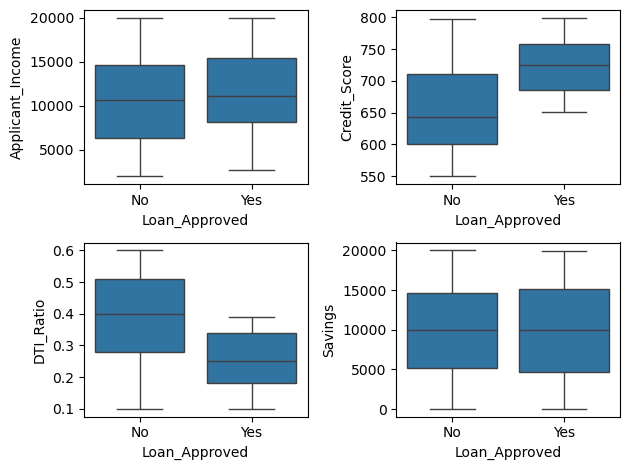

In [11]:
#outliers -box plots
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

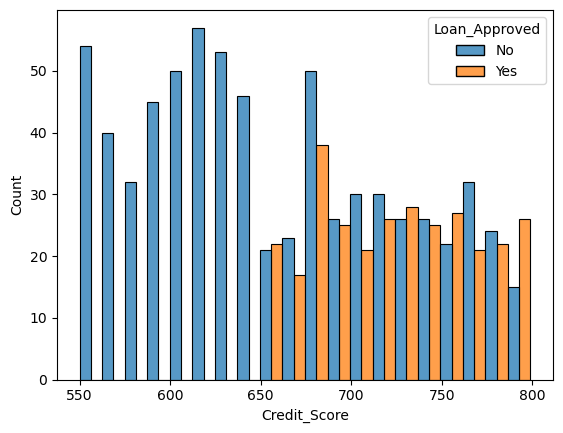

In [12]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge",
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

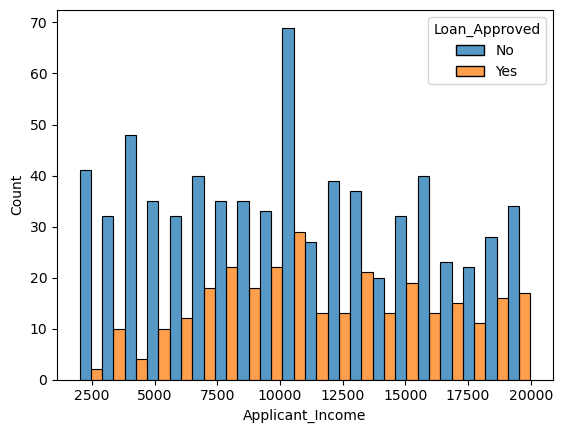

In [13]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge",
)

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

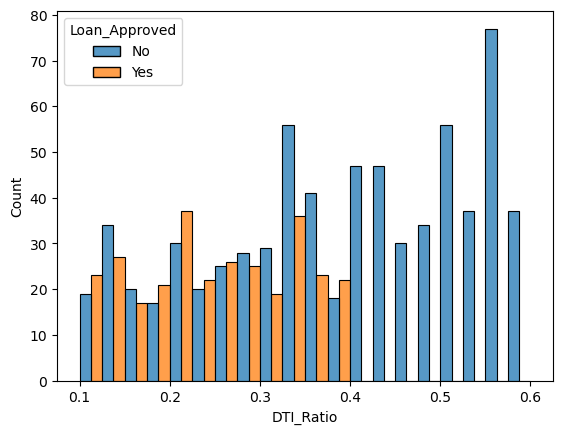

In [14]:
sns.histplot(
    data=df,
    x="DTI_Ratio",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge",
)

In [15]:
df=df.drop("Applicant_ID",axis=1)

In [16]:
df.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [17]:
df.sample(2)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
278,5009.0,6183.0,Unemployed,30.0,Single,1.0,745.0,4.0,0.50,3629.0,48135.0,29768.0,24.0,Business,Urban,Graduate,Male,Unemployed,No
173,3986.0,9996.0,Contract,51.0,Married,2.0,623.0,2.0,0.31,10326.0,16800.0,2885.0,84.0,Car,Urban,Not Graduate,Female,Private,No


In [18]:
#encoding
# Convert manually (BEST METHOD)
df["Education_Level"] = df["Education_Level"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

In [19]:
df["Loan_Approved"] = df["Loan_Approved"].map({
    "Yes": 1,
    "No": 0
})

In [20]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,0,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,1,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,1,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,1,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,1,Male,Private,1


In [21]:

cols = ["Employment_Status","Marital_Status","Loan_Purpose",
        "Property_Area","Gender","Employer_Category"] 

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)
df.sample(2)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
571,7997.0,3432.0,53.0,1.0,750.0,4.0,0.52,9940.452632,31736.0,25102.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
827,7373.0,4255.0,30.0,0.0,719.0,1.0,0.32,13406.000000,15021.0,24813.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


Corelation heatmap

In [22]:
#correlation heatmap
num_cols=df.select_dtypes("number")
corr_matrix=num_cols.corr()

<Axes: >

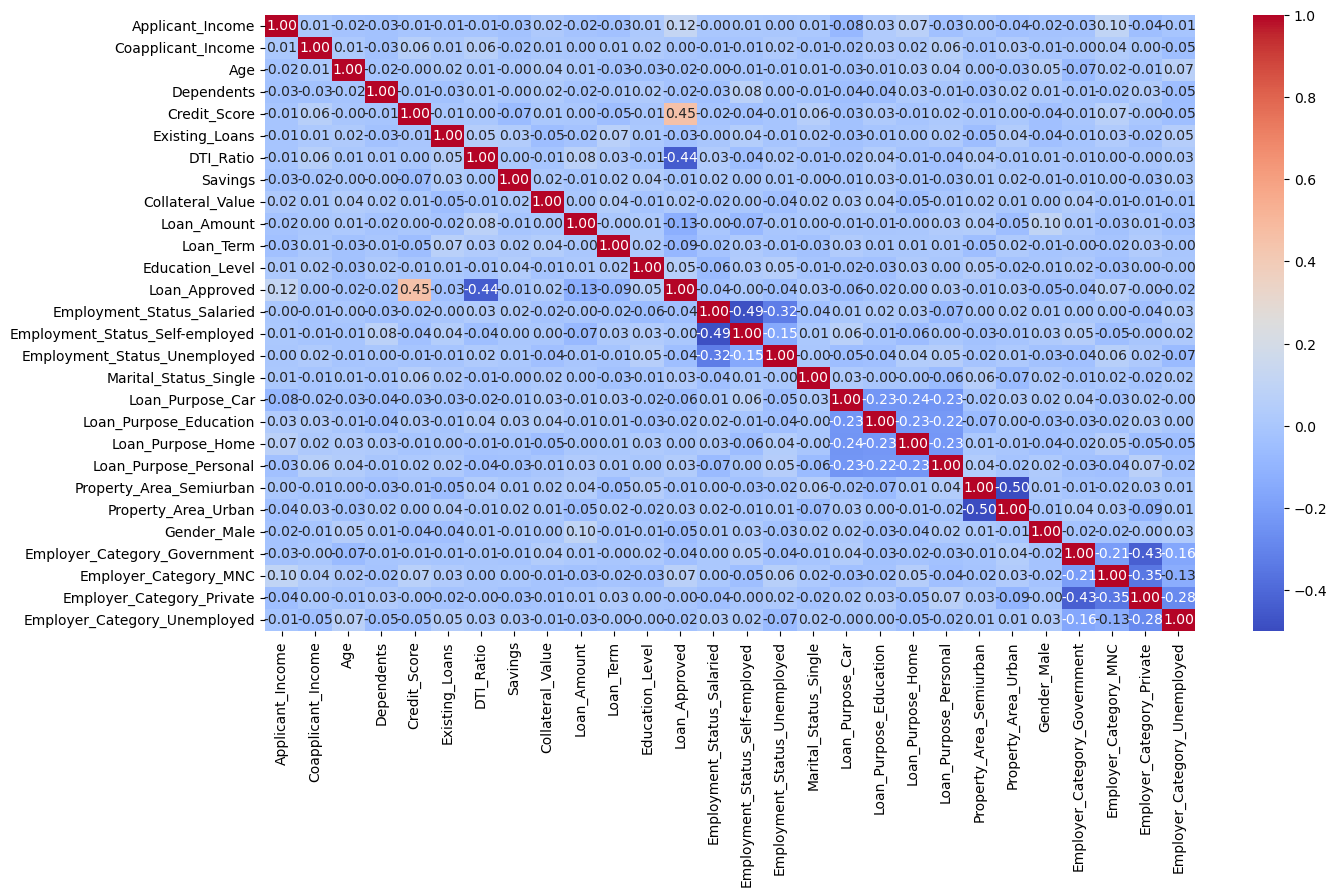

In [23]:
plt.figure(figsize =(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

Feature Enginnering

In [24]:


X=df.drop(columns=["Loan_Approved"])
y=df["Loan_Approved"]

feature_names = X.columns
joblib.dump(feature_names, "features.pkl")

#train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42)

#scaling

scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)



In [25]:
#using logisticRegression 
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train_scaler,y_train)
y_pred=model.predict(X_test_scaler)
#evalution
print("Logistic Regression")
print("Accuracy_score:",accuracy_score(y_test,y_pred))
print("Precision score:",precision_score(y_test,y_pred))
print("Recall score:",recall_score(y_test,y_pred))


Logistic Regression
Accuracy_score: 0.865
Precision score: 0.7833333333333333
Recall score: 0.7704918032786885


In [26]:
#save the trained model and scaler as pickle file

joblib.dump(model, "model.pkl")
joblib.dump(ohe, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']